In [63]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.gridspec as gridspec
from pathlib import Path

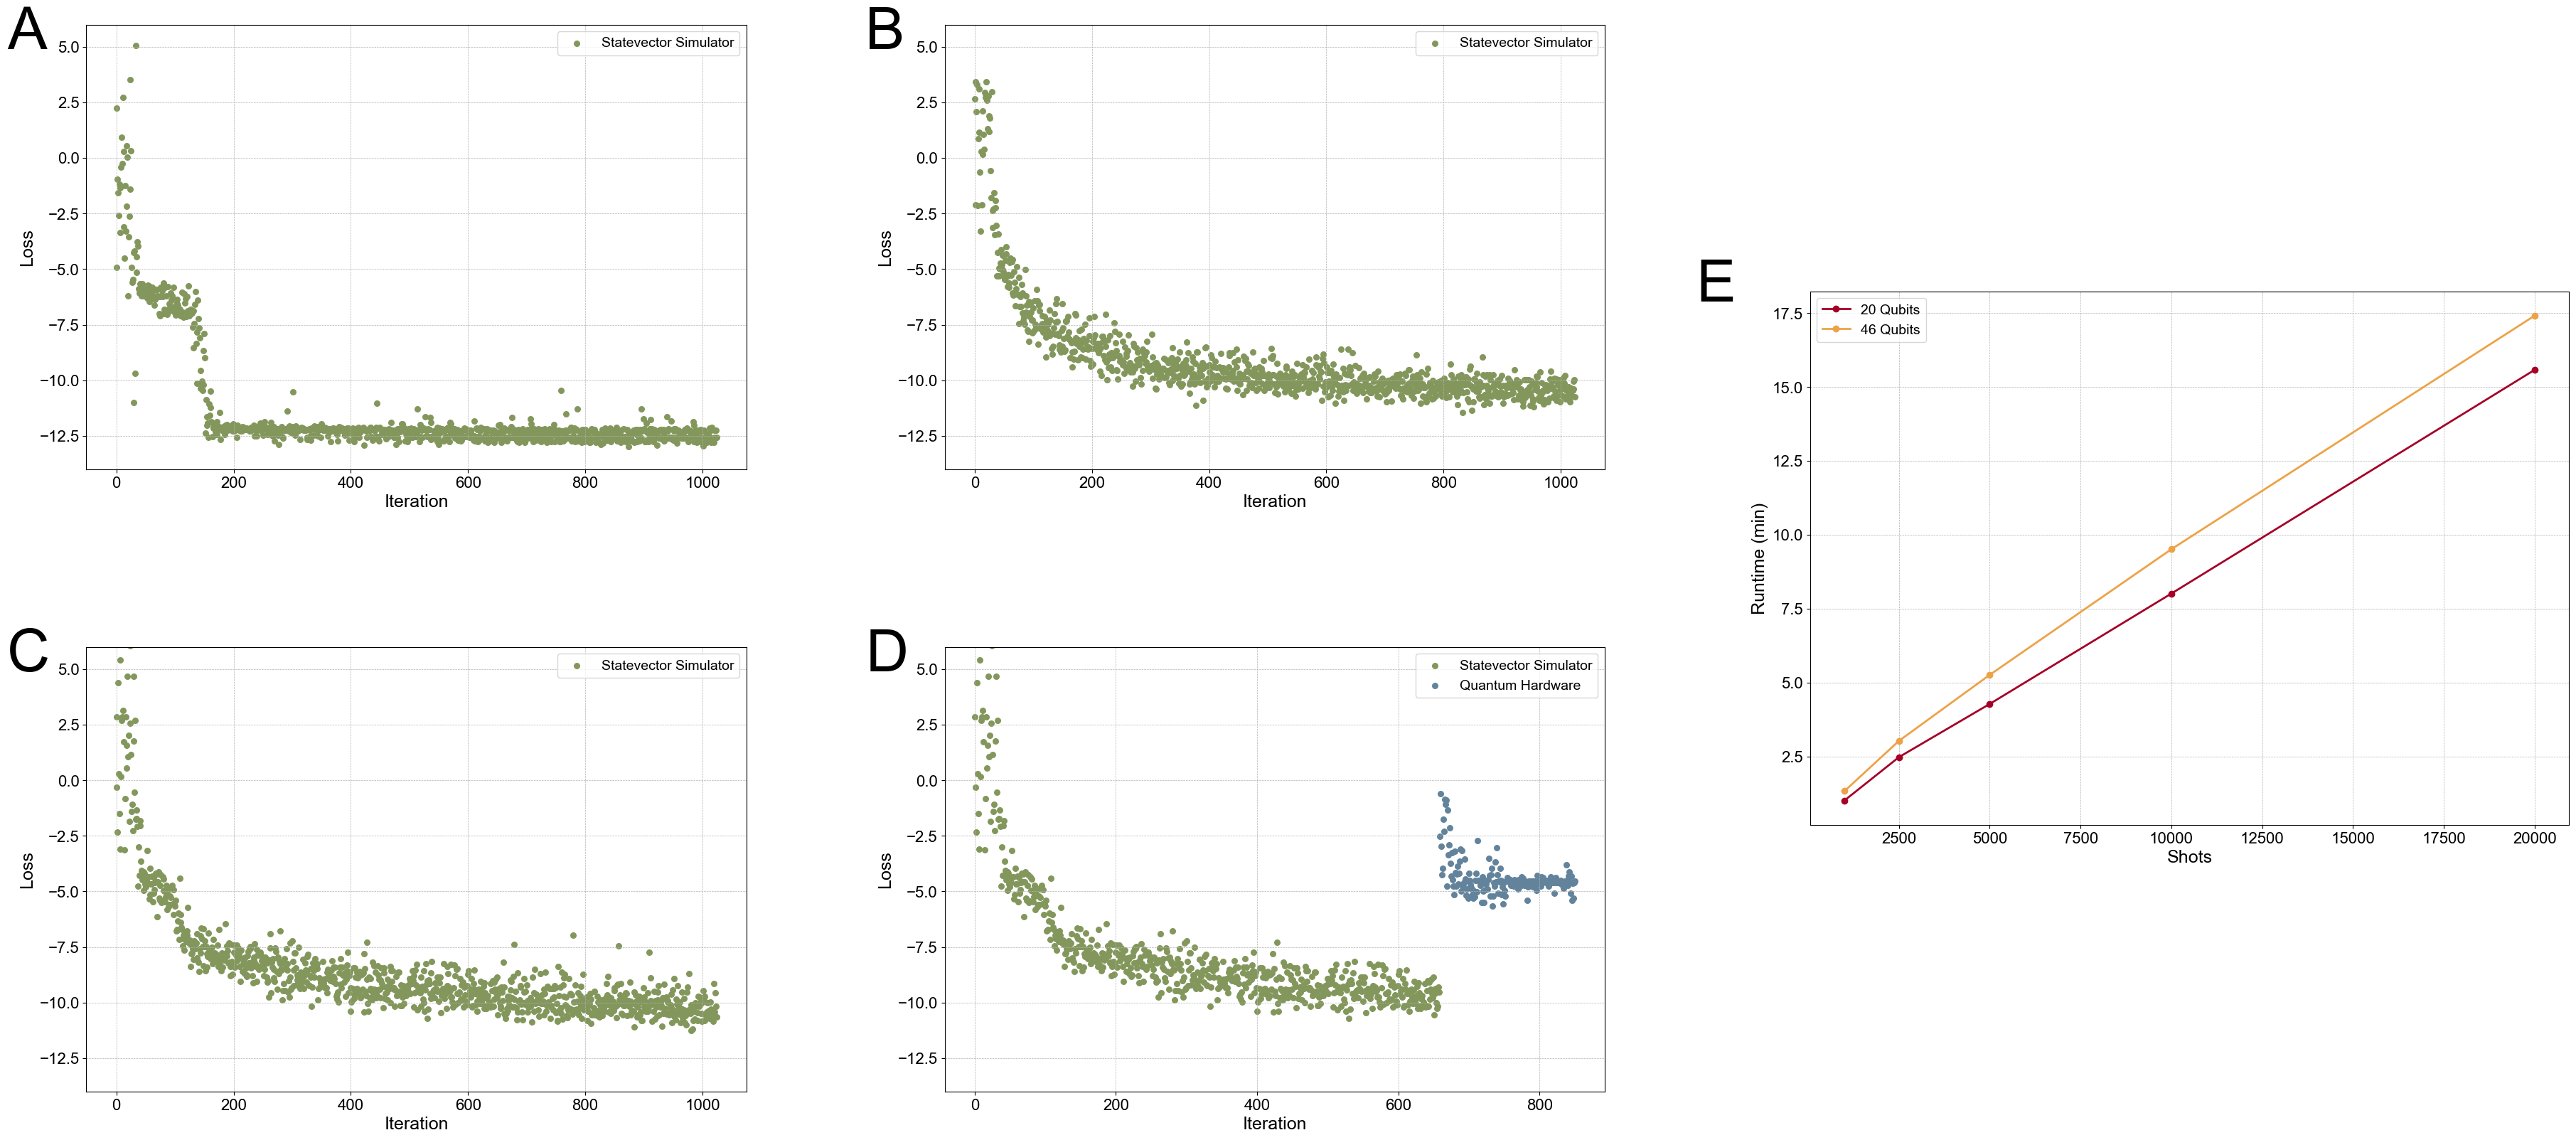

In [64]:
fig_font = 60
root_dir = Path().resolve().parents[1]

# ── colors ───────────────────────────────────────────────────────────────────
sim_color = (131/255, 151/255,  92/255)
hardware_color = ( 98/255, 131/255, 155/255)
color_1 = (165/255,   0/255,  38/255)
color_2 = (237/255, 162/255,  71/255)

# ── font ─────────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size']   = 16

# ── helpers ──────────────────────────────────────────────────────────────────
def load_loss(path):
    lv = np.load(path)
    lv = lv[1::2]
    it = list(range(len(lv)))
    return it, lv

def style_loss_ax(ax):
    ax.set_xlabel('Iteration', fontsize=18)
    ax.set_ylabel('Loss',      fontsize=18)
    ax.set_ylim(-14, 6)
    ax.grid(True, linestyle='--', linewidth=0.5)

# ── load data ─────────────────────────────────────────────────────────────────
it_a, lv_a = load_loss(root_dir / 'qcnn/experiments/exp2_binding_123ba/148ba_binding_objFuncVal.npy')
it_b, lv_b = load_loss(root_dir / 'qcnn/experiments/exp3_binding_1234/1348_binding_objFuncVal.npy')
it_c, lv_c = load_loss(root_dir / 'qcnn/experiments/exp4_binding_1234_basis_loaded/sim_1348_basis_objFuncVal.npy')

it_d_all, lv_d_all = load_loss(root_dir / 'qcnn/experiments/exp4_binding_1234_basis_loaded/load_1348_basis_objFuncVal.npy')
cutoff = 659
lv_d_sim = lv_d_all[:cutoff];  it_d_sim = it_d_all[:cutoff]
lv_d_hw  = lv_d_all[cutoff:];  it_d_hw  = it_d_all[cutoff:]

shots = [1000, 2500, 5000, 10000, 20000]
runtime_20q = [x / 60 for x in [61,  149, 257,  481,  935]]
runtime_46q = [x / 60 for x in [80,  182, 316,  571, 1045]]

# ── layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(36, 20))

# Outer: left 2×2 block | right block for E
outer_gs = gridspec.GridSpec(1, 2, figure=fig,
                             left=0.01, right=0.98,
                             top=0.90,  bottom=0.15,
                             wspace=0.18,
                             width_ratios=[2, 1])

# Left: 2×2 sub-grid
left_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[0], wspace=0.30, hspace=0.40)

ax_a = fig.add_subplot(left_gs[0, 0])
ax_b = fig.add_subplot(left_gs[0, 1])
ax_c = fig.add_subplot(left_gs[1, 0])
ax_d = fig.add_subplot(left_gs[1, 1])

# Right: 3-row sub-grid → E occupies the middle row only (top/bottom rows are padding)
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[1], height_ratios=[2, 4, 2], hspace=0)
ax_e = fig.add_subplot(right_gs[1])

# ── panel A ──────────────────────────────────────────────────────────────────
ax_a.scatter(it_a, lv_a, color=sim_color, label='Statevector Simulator', s=30)
style_loss_ax(ax_a)
ax_a.legend(loc='best', fontsize=14)
ax_a.text(-0.12, 1.04, 'A', transform=ax_a.transAxes, fontsize=fig_font, va='top')

# ── panel B ──────────────────────────────────────────────────────────────────
ax_b.scatter(it_b, lv_b, color=sim_color, label='Statevector Simulator', s=30)
style_loss_ax(ax_b)
ax_b.legend(loc='best', fontsize=14)
ax_b.text(-0.12, 1.04, 'B', transform=ax_b.transAxes, fontsize=fig_font, va='top')

# ── panel C ──────────────────────────────────────────────────────────────────
ax_c.scatter(it_c, lv_c, color=sim_color, label='Statevector Simulator', s=30)
style_loss_ax(ax_c)
ax_c.legend(loc='best', fontsize=14)
ax_c.text(-0.12, 1.04, 'C', transform=ax_c.transAxes, fontsize=fig_font, va='top')

# ── panel D ──────────────────────────────────────────────────────────────────
ax_d.scatter(it_d_sim, lv_d_sim, color=sim_color, label='Statevector Simulator', s=30)
ax_d.scatter(it_d_hw, lv_d_hw, color=hardware_color, label='Quantum Hardware', s=30)
style_loss_ax(ax_d)
ax_d.legend(loc='best', fontsize=14)
ax_d.text(-0.12, 1.04, 'D', transform=ax_d.transAxes, fontsize=fig_font, va='top')

# ── panel E ──────────────────────────────────────────────────────────────────
ax_e.plot(shots, runtime_20q, color=color_1, marker='o', label='20 Qubits', linewidth=2, markersize=6)
ax_e.plot(shots, runtime_46q, color=color_2, marker='o', label='46 Qubits', linewidth=2, markersize=6)
ax_e.set_xlabel('Shots', fontsize=18)
ax_e.set_ylabel('Runtime (min)', fontsize=18)
ax_e.grid(True, linestyle='--', linewidth=0.5)
ax_e.legend(loc='best', fontsize=14)
ax_e.text(-0.15, 1.06, 'E', transform=ax_e.transAxes, fontsize=fig_font, va='top')

plt.savefig('binding_plots.svg', dpi=150, bbox_inches='tight')
plt.savefig('binding_plots.pdf', dpi=150, bbox_inches='tight')